<a href="https://colab.research.google.com/github/Pablolpl/ml-finanzas/blob/main/CASO_series_temporales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caso Práctico: Modelización de Series Temporales del índice S&P 500

**Asignatura:** Predicción Inteligente: Inteligencia
Artificial para el Análisis de Precios en
Mercados Financieros

**Docente:** Lucía Peirano

**Alumno:** Pablo Lamas Pillo  

**Máster en Inteligencia Artificial aplicada al Sector Financiero — Instituto Europeo de Posgrado**

---

## Objetivo

El propósito de esta práctica es aplicar el ciclo completo de la metodología Box–Jenkins sobre
los precios de cierre diarios del índice **S&P 500 (spx)**, contenidos en el fichero
`Index2018.xlsx` (6.269 observaciones entre 1994-01-07 y 2018-01-29).

El trabajo se organiza en las ocho tareas del enunciado: importación y control de tipos,
análisis gráfico, contraste de estacionariedad, diferenciación, identificación de órdenes
mediante ACF/PACF, estimación del modelo ARIMA, diagnóstico de residuos y propuesta de mejoras.

A lo largo del caso traduzco cada resultado estadístico a su lectura de negocio. Trabajo en
banca comercial y privada con producto de inversión, y me interesa especialmente qué implica
cada hallazgo para la previsión de un índice, para la medición del riesgo y para lo que
razonablemente puede transmitirse a un cliente.

## 0. Configuración del entorno

Instalo `openpyxl` (necesario para leer ficheros `.xlsx`, no siempre presente en Colab) y
`arch`, que utilizaré en la Tarea 8 para el ajuste del modelo GARCH. A continuación importo
las librerías de trabajo y fijo los parámetros gráficos por defecto.

In [1]:
!pip install -q openpyxl arch --upgrade

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("OK")

OK


## Tarea 1. Importación del fichero y preparación de los datos

**Fundamento teórico.** Una serie temporal es una secuencia de observaciones indexada por el tiempo en la que el orden **no es intercambiable**: toda la información relevante para el modelado —autocorrelación, tendencia, volatilidad condicional— reside precisamente en la dependencia entre observaciones consecutivas. Por ello, garantizar el tipo `datetime`, el orden ascendente y una frecuencia explícita no es una formalidad, sino un requisito para que los contrastes y los modelos posteriores queden correctamente especificados.

Cargo el fichero y realizo una inspección inicial de dimensiones, tipos y valores ausentes.

In [3]:
from google.colab import files
subido = files.upload()

nombre = list(subido.keys())[0]
print("Archivo subido:", nombre)

df_raw = pd.read_excel(nombre)
print("Dimensión:", df_raw.shape)
print(df_raw.dtypes)
df_raw.head()

Saving Index2018 2.xlsx to Index2018 2 (5).xlsx
Archivo subido: Index2018 2 (5).xlsx
Dimensión: (6269, 5)
date      datetime64[ns]
spx              float64
dax              float64
ftse             float64
nikkei           float64
dtype: object


,date,spx,dax,ftse,nikkei
0,1994-01-07,469.90,2224.95,3445.98,18124.01
1,1994-01-10,475.27,2225.00,3440.58,18443.44
2,1994-01-11,474.13,2228.10,3413.77,18485.25
3,1994-01-12,474.17,2182.06,3372.02,18793.88
4,1994-01-13,472.47,2142.37,3360.01,18577.26


### 1.1. Conversión de tipos y ordenación cronológica

Convierto `date` a `datetime`, fuerzo los cuatro índices a tipo numérico y ordeno la tabla cronológicamente antes de establecer la fecha como índice. El parámetro `errors="coerce"` transforma en `NaN` cualquier valor que no pueda convertirse, lo que me permite detectarlo en el recuento de nulos en lugar de arrastrar un error silencioso.

In [4]:
df = df_raw.copy()
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

for col in ["spx", "dax", "ftse", "nikkei"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("date").set_index("date")

print(df.dtypes)
print(f"\nRango: {df.index.min().date()} a {df.index.max().date()}")
print(f"Observaciones: {len(df)}")
print("\nNulos:\n", df.isna().sum())
df.describe()

spx       float64
dax       float64
ftse      float64
nikkei    float64
dtype: object

Rango: 1994-01-07 a 2018-01-29
Observaciones: 6269

Nulos:
 spx       0
dax       0
ftse      0
nikkei    0
dtype: int64


,spx,dax,ftse,nikkei
count,6269.000000,6269.000000,6269.000000,6269.000000
mean,1288.127542,6080.063363,5422.713545,14597.055700
std,487.586473,2754.361032,1145.572428,4043.122953
min,438.920000,1911.700000,2876.600000,7054.980000
25%,990.671905,4069.350000,4486.100000,10709.290000
50%,1233.420000,5773.340000,5662.430000,15028.170000
75%,1459.987747,7443.070000,6304.250000,17860.470000
max,2872.867839,13559.600000,7778.637689,24124.150000


### 1.2. Asignación de frecuencia y tratamiento de festivos

Los mercados no cotizan fines de semana ni festivos, de modo que la serie presenta huecos irregulares. Sin una frecuencia declarada, `statsmodels` emite avisos y pierde la referencia de fechas en las predicciones.

Asigno frecuencia de **día hábil** (`'B'`, *business day*) y relleno los festivos resultantes con el último cierre disponible (`ffill`). Es la convención habitual en la industria: un día sin cotización no constituye un dato perdido, sino un día en el que el precio de referencia **sigue siendo el cierre anterior**. Así es exactamente como se valoran las carteras a efectos de reporting al cliente.

In [5]:
df = df.asfreq("B")
print("NaN tras asignar frecuencia B (festivos):\n", df.isna().sum())

df = df.ffill()
print("\nNulos tras ffill:\n", df.isna().sum())
print("Observaciones finales:", len(df))

spx = df["spx"].copy()
spx.head()

NaN tras asignar frecuencia B (festivos):
 spx       8
dax       8
ftse      8
nikkei    8
dtype: int64

Nulos tras ffill:
 spx       0
dax       0
ftse      0
nikkei    0
dtype: int64
Observaciones finales: 6277


,spx
date,
1994-01-07,469.90
1994-01-10,475.27
1994-01-11,474.13
1994-01-12,474.17
1994-01-13,472.47


## Tarea 2. Representación gráfica. Tendencia y estacionariedad

**Fundamento teórico.** Una serie es **estacionaria en sentido débil** si su media, su varianza y su función de autocovarianza no dependen del momento del tiempo, sino únicamente del desfase entre observaciones. La estacionariedad es el supuesto que permite que los parámetros estimados sobre el pasado sigan siendo válidos hacia el futuro; sin ella, la inferencia no es extrapolable y aparecen las llamadas *regresiones espurias*.

Represento en primer lugar la evolución completa del índice.

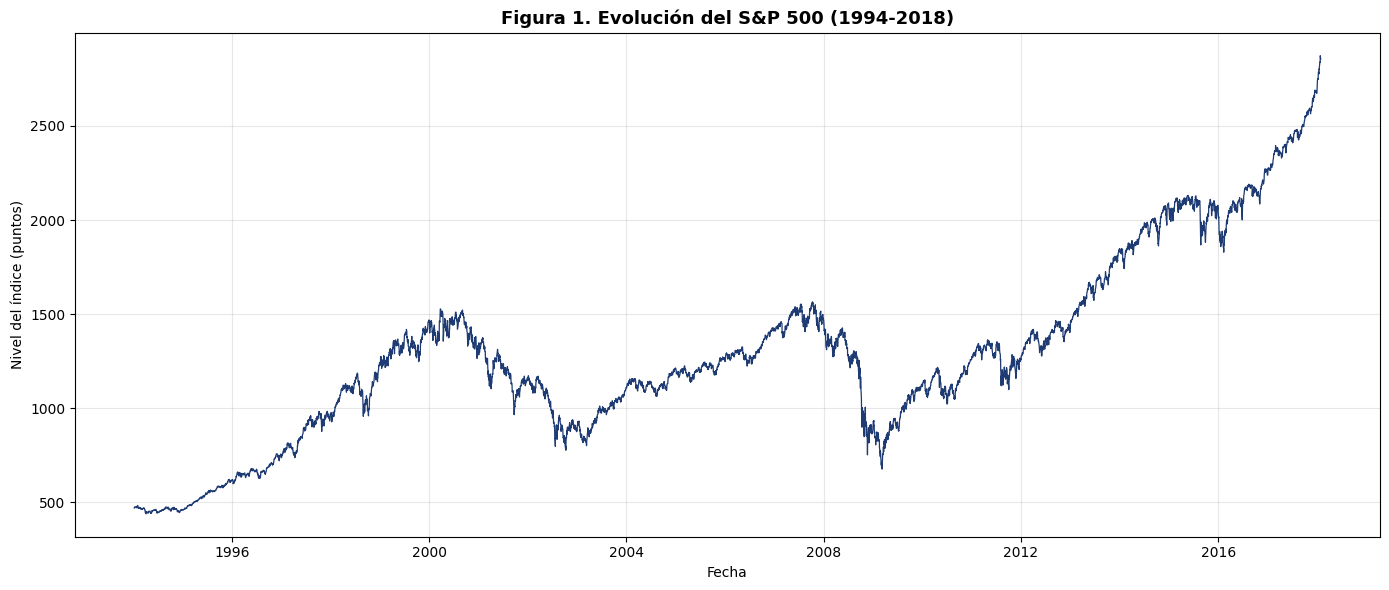

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(spx.index, spx.values, linewidth=0.9, color="#1f3b73")
ax.set_title("Figura 1. Evolución del S&P 500 (1994-2018)", fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Nivel del índice (puntos)")
plt.tight_layout()
plt.show()

### 2.1. Media y desviación típica móviles

Calculo ambos estadísticos sobre una ventana de 252 días hábiles (un año bursátil). Si media y dispersión derivan sistemáticamente con el tiempo, dispongo de evidencia visual contra la estacionariedad antes incluso de aplicar ningún contraste formal.

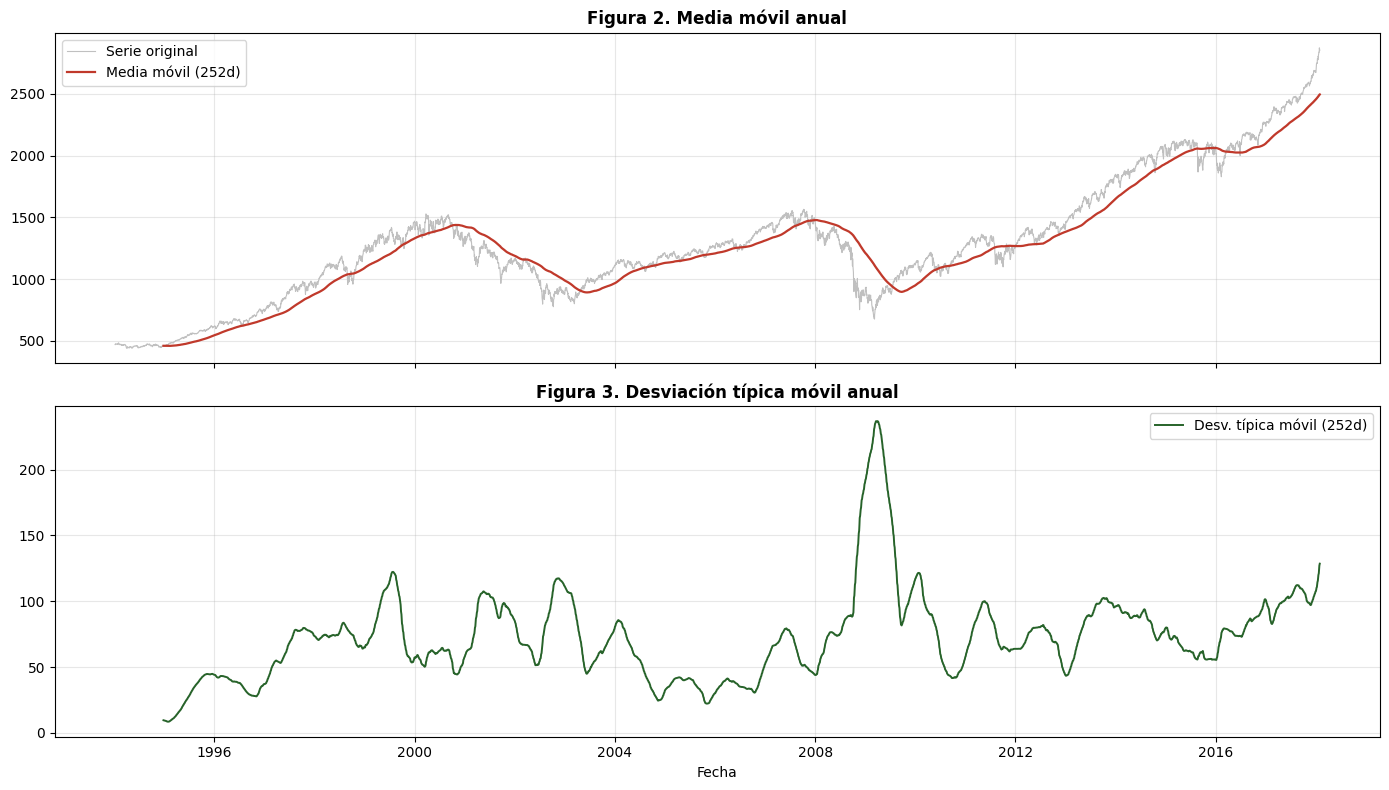

In [7]:
ventana = 252

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(spx, color="#c0c0c0", linewidth=0.8, label="Serie original")
axes[0].plot(spx.rolling(ventana).mean(), color="#c0392b", linewidth=1.6,
             label=f"Media móvil ({ventana}d)")
axes[0].set_title("Figura 2. Media móvil anual", fontweight="bold")
axes[0].legend()

axes[1].plot(spx.rolling(ventana).std(), color="#27632a", linewidth=1.4,
             label=f"Desv. típica móvil ({ventana}d)")
axes[1].set_title("Figura 3. Desviación típica móvil anual", fontweight="bold")
axes[1].set_xlabel("Fecha")
axes[1].legend()

plt.tight_layout()
plt.show()

### Comentario

De la Figura 1 se desprende una **tendencia claramente creciente a largo plazo**, interrumpida por dos episodios de caída severa perfectamente identificables: el estallido de la burbuja *dot-com* (2000–2002) y la crisis financiera global (2007–2009), con un tramo alcista muy sostenido a partir de 2013.

La Figura 2 confirma que **la media no es constante**: la media móvil anual parte de niveles próximos a los 450 puntos a mediados de los noventa y supera los 2.500 puntos al final de la muestra, lo que supone multiplicar por más de cinco el nivel medio del índice en poco más de dos décadas. La curva roja no oscila en torno a un valor de equilibrio, sino que deriva sistemáticamente al alza, con dos únicos periodos de retroceso que coinciden exactamente con las crisis señaladas.

La Figura 3 muestra que **la varianza tampoco es constante**. La desviación típica móvil se mueve en un rango muy amplio, desde valores inferiores a 30 puntos en los tramos de calma de mediados de los noventa hasta un máximo próximo a 235 puntos en 2009, con picos intermedios en torno a 120 puntos en 1999–2000 y 2002. El perfil es marcadamente irregular y alterna fases de compresión con repuntes abruptos: es el patrón de *agrupamiento de la volatilidad* (**volatility clustering**), un hecho estilizado universal de las series financieras.

Conviene matizar que la desviación típica está expresada en puntos del índice, de modo que parte de su crecimiento a lo largo de la muestra refleja simplemente el mayor nivel absoluto del S&P 500. Aun así, el episodio de 2009 destaca muy por encima de esa escala: casi duplica cualquier otro máximo de la serie, lo que confirma que se trata de un aumento genuino de la volatilidad y no de un efecto de escala. Este punto justifica trabajar con rendimientos logarítmicos en la Tarea 8.

**Conclusión:** la serie en niveles no es estacionaria ni en media ni en varianza. Resulta necesario transformarla antes de modelizar.

## Tarea 3. Contraste de Dickey-Fuller aumentado (ADF)

**Fundamento teórico.** El contraste ADF verifica la presencia de una **raíz unitaria** en el proceso generador de datos. Se plantea sobre la regresión

$$\Delta y_t = \alpha + \beta t + \gamma\, y_{t-1} + \sum_{i=1}^{k}\delta_i \Delta y_{t-i} + \varepsilon_t$$

con las hipótesis:

- $H_0:\ \gamma = 0$ → existe raíz unitaria → la serie **no** es estacionaria.
- $H_1:\ \gamma < 0$ → la serie **es** estacionaria.

El estadístico no sigue una *t* de Student convencional, sino la distribución de Dickey-Fuller, por lo que debe compararse con valores críticos tabulados específicos. Un *p*-valor superior a 0,05 implica **no rechazar** $H_0$ y, en consecuencia, aceptar la existencia de raíz unitaria.

Complemento el ADF con el contraste **KPSS**, cuyas hipótesis están invertidas ($H_0$: la serie **sí** es estacionaria). Cuando ambos apuntan en la misma dirección, la conclusión resulta considerablemente más robusta que apoyándose en uno solo.

Defino a continuación dos funciones auxiliares que devuelven un informe legible de cada contraste.

In [8]:
def informe_adf(serie, nombre="Serie"):
    serie = serie.dropna()
    estad, pvalor, n_lags, n_obs, criticos, _ = adfuller(serie, autolag="AIC")
    print("=" * 62)
    print(f"ADF — {nombre}")
    print("=" * 62)
    print(f"Estadístico ADF : {estad:>12.4f}")
    print(f"p-valor         : {pvalor:>12.4f}")
    print(f"Lags            : {n_lags:>12d}")
    print(f"Observaciones   : {n_obs:>12d}")
    for k, v in criticos.items():
        print(f"Valor crítico {k:>4}: {v:>10.4f}")
    print("-" * 62)
    print("RECHAZO H0 → ESTACIONARIA" if pvalor <= 0.05
          else "NO rechazo H0 → hay raíz unitaria → NO ESTACIONARIA")
    print("=" * 62)
    return pvalor


def informe_kpss(serie, nombre="Serie"):
    estad, pvalor, n_lags, criticos = kpss(serie.dropna(), regression="c", nlags="auto")
    print(f"\nKPSS — {nombre}")
    print(f"Estadístico: {estad:.4f} | p-valor: {pvalor:.4f}")
    print("RECHAZO H0 → NO ESTACIONARIA" if pvalor <= 0.05
          else "NO rechazo H0 → ESTACIONARIA")
    return pvalor

### 3.1. Aplicación sobre la serie en niveles

In [9]:
informe_adf(spx, "S&P 500 en niveles")
informe_kpss(spx, "S&P 500 en niveles")

ADF — S&P 500 en niveles
Estadístico ADF :       1.1195
p-valor         :       0.9954
Lags            :           10
Observaciones   :         6266
Valor crítico   1%:    -3.4314
Valor crítico   5%:    -2.8620
Valor crítico  10%:    -2.5670
--------------------------------------------------------------
NO rechazo H0 → hay raíz unitaria → NO ESTACIONARIA

KPSS — S&P 500 en niveles
Estadístico: 8.6804 | p-valor: 0.0100
RECHAZO H0 → NO ESTACIONARIA


/tmp/ipykernel_30270/2712133838.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  estad, pvalor, n_lags, criticos = kpss(serie.dropna(), regression="c", nlags="auto")


np.float64(0.01)

### Comentario

El contraste ADF sobre la serie en niveles arroja un estadístico de **1,1195** y un *p*-valor de **0,9954**, muy por encima del umbral del 5%, de modo que **no se rechaza la hipótesis nula de raíz unitaria**. El estadístico queda además muy por encima de los tres valores críticos (−3,4314 al 1%, −2,8620 al 5% y −2,5670 al 10%), lo que confirma el resultado con holgura en cualquiera de los tres niveles de significación.

Merece la pena detenerse en el **signo positivo** del estadístico. El contraste evalúa si el coeficiente γ del término $y_{t-1}$ es negativo, es decir, si existe una fuerza que devuelva la serie hacia su media. Un valor positivo indica que no solo no hay reversión a la media, sino que el comportamiento es coherente con un proceso explosivo o con deriva al alza. No estamos ante un caso límite en el que la decisión dependa del nivel de significación elegido: la no estacionariedad es inequívoca.

El contraste KPSS apunta en la misma dirección con un estadístico de **8,6804** y un *p*-valor de **0,01**, rechazando su hipótesis nula de estacionariedad. Cabe señalar que este *p*-valor está truncado por la tabla de valores críticos —`statsmodels` emite un aviso al respecto—, de modo que el verdadero *p*-valor es inferior al reportado, lo que refuerza aún más el rechazo. La coincidencia de ambos contrastes, pese a plantear hipótesis nulas opuestas, elimina cualquier ambigüedad en el diagnóstico.

**Justificación de la necesidad de diferenciar:** los dos contrastes coinciden entre sí y con la evidencia gráfica de las Figuras 1 a 3. La serie de niveles del S&P 500 se comporta como un proceso integrado de orden 1, próximo a un paseo aleatorio con deriva. Este resultado es coherente con la hipótesis de eficiencia de mercado en forma débil: el nivel del índice hoy constituye la mejor predicción disponible del nivel de mañana, y no existe un valor de equilibrio hacia el que la serie tienda a revertir. Resulta por tanto imprescindible

## Tarea 4. Diferenciación de la serie: determinación de *d*

**Fundamento teórico.** Diferenciar consiste en sustituir el nivel por su variación: $\Delta y_t = y_t - y_{t-1}$. Cada diferencia elimina una raíz unitaria. El orden de integración *d* es el número **mínimo** de diferencias necesario para alcanzar la estacionariedad.

Es importante no **sobrediferenciar**: aplicar más diferencias de las necesarias introduce autocorrelación negativa artificial en el término de error, infla la varianza de la serie y degrada la capacidad predictiva del modelo.

Represento la primera diferencia junto con su distribución y sus estadísticos descriptivos.

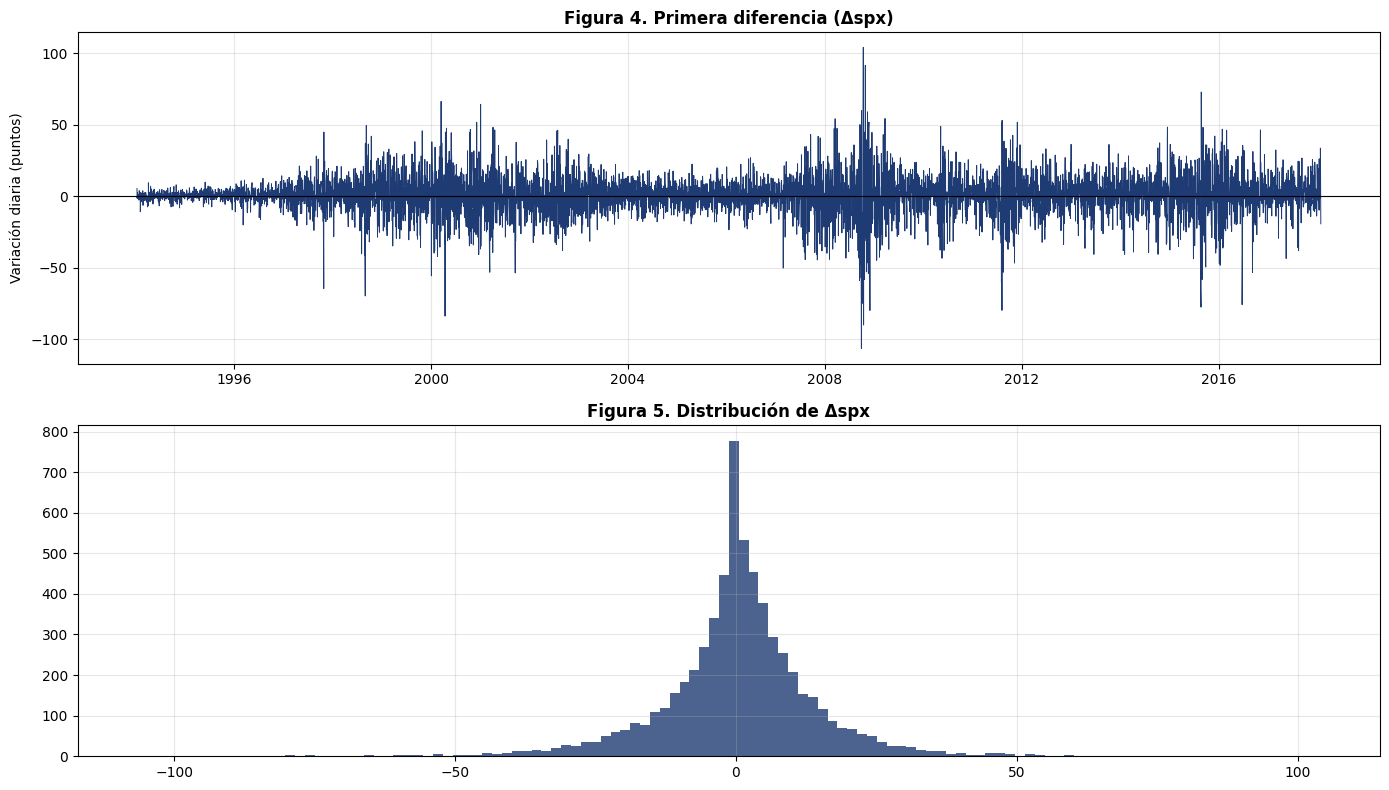

Media     : 0.3798
Desv. tip.: 13.5532
Asimetría : -0.3155
Curtosis  : 5.1589


In [10]:
spx_d1 = spx.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(spx_d1, linewidth=0.7, color="#1f3b73")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Figura 4. Primera diferencia (Δspx)", fontweight="bold")
axes[0].set_ylabel("Variación diaria (puntos)")

axes[1].hist(spx_d1, bins=120, color="#1f3b73", alpha=0.8)
axes[1].set_title("Figura 5. Distribución de Δspx", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Media     : {spx_d1.mean():.4f}")
print(f"Desv. tip.: {spx_d1.std():.4f}")
print(f"Asimetría : {spx_d1.skew():.4f}")
print(f"Curtosis  : {spx_d1.kurtosis():.4f}")

### 4.1. Contraste sobre la serie diferenciada y control de la sobrediferenciación

Aplico ADF y KPSS sobre la primera diferencia. Adicionalmente calculo la segunda diferencia y comparo varianzas: si $Var(\Delta^2 y_t) > Var(\Delta y_t)$, la segunda diferencia está introduciendo ruido en lugar de eliminar estructura, lo que confirma que basta con $d=1$.

In [11]:
informe_adf(spx_d1, "Δspx (d=1)")
informe_kpss(spx_d1, "Δspx (d=1)")

spx_d2 = spx.diff().diff().dropna()
informe_adf(spx_d2, "Δ²spx (d=2)")

print(f"\nVar(Δspx)  = {spx_d1.var():,.2f}")
print(f"Var(Δ²spx) = {spx_d2.var():,.2f}")
print("→ Sobrediferenciación, se fija d=1" if spx_d2.var() > spx_d1.var()
      else "→ Revisar")

ADF — Δspx (d=1)
Estadístico ADF :     -14.1684
p-valor         :       0.0000
Lags            :           34
Observaciones   :         6241
Valor crítico   1%:    -3.4314
Valor crítico   5%:    -2.8620
Valor crítico  10%:    -2.5670
--------------------------------------------------------------
RECHAZO H0 → ESTACIONARIA

KPSS — Δspx (d=1)
Estadístico: 0.3449 | p-valor: 0.1000
NO rechazo H0 → ESTACIONARIA


/tmp/ipykernel_30270/2712133838.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  estad, pvalor, n_lags, criticos = kpss(serie.dropna(), regression="c", nlags="auto")


ADF — Δ²spx (d=2)
Estadístico ADF :     -24.6505
p-valor         :       0.0000
Lags            :           31
Observaciones   :         6243
Valor crítico   1%:    -3.4314
Valor crítico   5%:    -2.8620
Valor crítico  10%:    -2.5670
--------------------------------------------------------------
RECHAZO H0 → ESTACIONARIA

Var(Δspx)  = 183.69
Var(Δ²spx) = 388.28
→ Sobrediferenciación, se fija d=1


### Comentario

Tras aplicar una única diferencia, el ADF arroja un estadístico de **−14,1684** y un *p*-valor de **0,0000**, muy por debajo del valor crítico al 1% (−3,4314): **se rechaza contundentemente la hipótesis de raíz unitaria**. El contraste ha pasado de un estadístico positivo (1,1195) en niveles a uno fuertemente negativo, lo que indica que la serie diferenciada sí presenta reversión a la media.

El KPSS confirma el diagnóstico desde el lado opuesto: con un estadístico de **0,3449** y un *p*-valor de **0,1000** no se rechaza su hipótesis nula de estacionariedad. El aviso de `statsmodels` señala aquí que el verdadero *p*-valor es **superior** al reportado, de modo que el no rechazo es todavía más holgado de lo que sugiere la cifra. Es la situación ideal: ADF rechaza raíz unitaria y KPSS no rechaza estacionariedad, ambos apuntando a la misma conclusión. La Figura 4 respalda visualmente el resultado, con una serie que oscila en torno a cero sin tendencia apreciable.

**Descarte de la segunda diferencia.** El ADF sobre Δ²spx también rechaza la hipótesis nula, con un estadístico aún más negativo (−24,6505). Sin embargo, este resultado no debe interpretarse como evidencia a favor de d=2: una serie sobrediferenciada sigue superando el ADF, precisamente porque la diferenciación adicional genera autocorrelación negativa artificial en el término de error, que el contraste lee como reversión a la media. El estadístico más extremo es aquí un síntoma del problema, no una mejora.

El criterio decisivo es la comparación de varianzas: **Var(Δspx) = 183,69** frente a **Var(Δ²spx) = 388,28**. La segunda diferencia **más que duplica la varianza** de la primera, señal inequívoca de sobrediferenciación. Aplicarla implicaría introducir ruido en lugar de eliminar estructura, inflando el error de predicción sin ganancia alguna en estacionariedad.

**Conclusión de la Tarea 4: d = 1.**

Un matiz relevante desde el punto de vista financiero: la Figura 4 evidencia que, aunque la media resulta ya estable, **la varianza continúa sin serlo**. Los movimientos de mayor magnitud se concentran en 2008–2009 y en 2001–2002, exactamente los periodos identificados en la Figura 3. La diferenciación resuelve la no estacionariedad en media, pero no la heterocedasticidad condicional, que permanece intacta. Este punto será determinante en el diagnóstico de residuos de la Tarea 7 y constituye la principal limitación del enfoque ARIMA sobre series financieras.

## Tarea 5. Funciones de autocorrelación (ACF) y autocorrelación parcial (PACF)

**Fundamento teórico.**

- La **ACF** mide la correlación entre $y_t$ e $y_{t-k}$ incluyendo los efectos indirectos transmitidos por los retardos intermedios. Identifica el orden **q** del componente de medias móviles: un MA(q) puro presenta una ACF que **se corta bruscamente** tras el retardo *q*.
- La **PACF** mide esa misma correlación **eliminando** el efecto de los retardos intermedios. Identifica el orden **p** del componente autorregresivo: un AR(p) puro presenta una PACF que **se corta** tras el retardo *p*.
- Un proceso ARMA(p,q) mixto muestra **decaimiento gradual en ambas** funciones, sin corte limpio.

Las bandas sombreadas representan el intervalo de confianza al 95% bajo la hipótesis de ruido blanco ($\pm 1{,}96/\sqrt{T}$). Con $T \approx 6.269$ observaciones estas bandas son muy estrechas, de modo que barras estadísticamente significativas pueden resultar económicamente irrelevantes. Conviene tenerlo presente al interpretar.

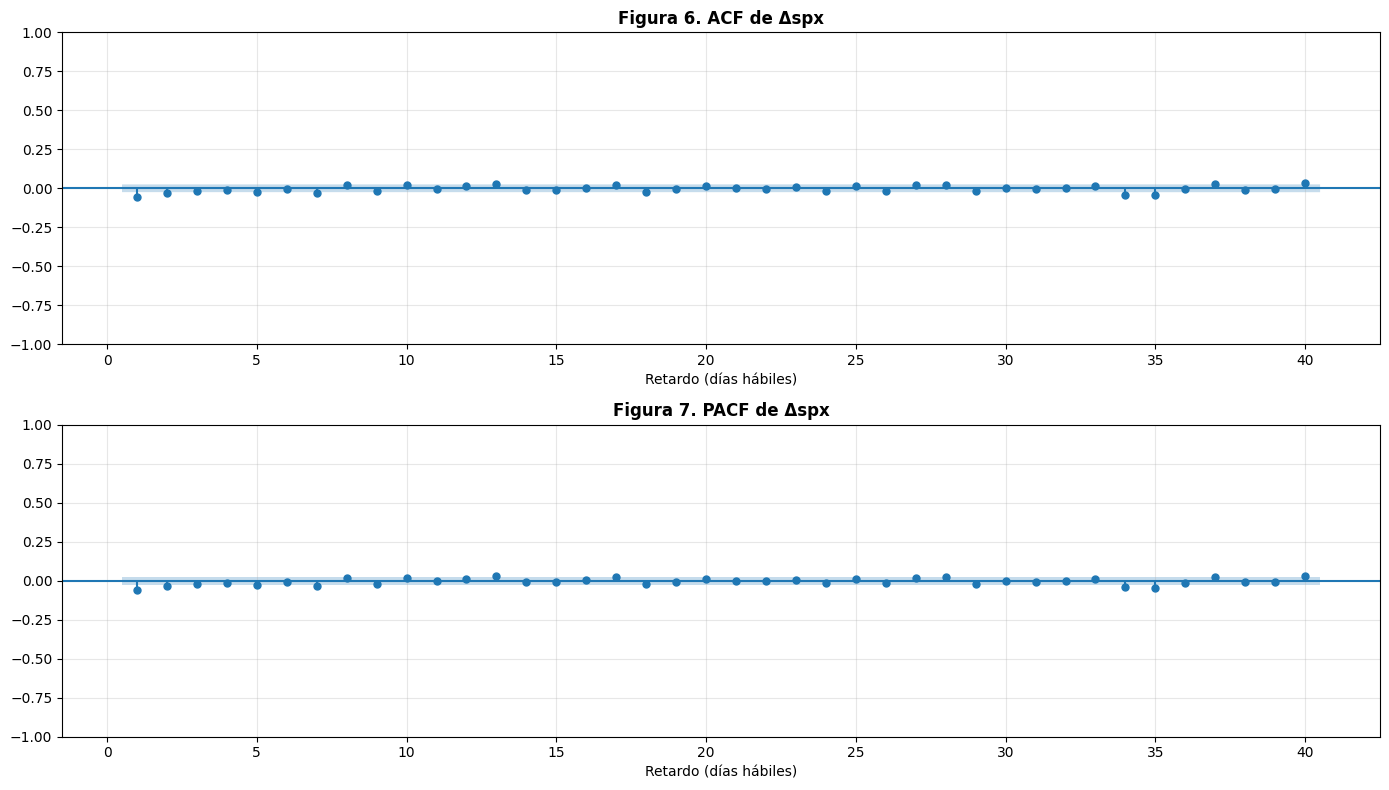

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(spx_d1, lags=40, ax=axes[0], alpha=0.05, zero=False)
axes[0].set_title("Figura 6. ACF de Δspx", fontweight="bold")
axes[0].set_xlabel("Retardo (días hábiles)")

plot_pacf(spx_d1, lags=40, ax=axes[1], alpha=0.05, method="ywm", zero=False)
axes[1].set_title("Figura 7. PACF de Δspx", fontweight="bold")
axes[1].set_xlabel("Retardo (días hábiles)")

plt.tight_layout()
plt.show()

### 5.1. Identificación numérica de los retardos significativos

La lectura visual resulta insuficiente con muestras de este tamaño, por lo que extraigo los valores numéricos de ambas funciones y los contrasto explícitamente contra la banda de confianza.

In [13]:
n = len(spx_d1)
banda = 1.96 / np.sqrt(n)

acf_val = acf(spx_d1, nlags=20)
pacf_val = pacf(spx_d1, nlags=20, method="ywm")

tabla = pd.DataFrame({"Retardo": range(21), "ACF": acf_val, "PACF": pacf_val})
tabla["ACF_signif"] = tabla["ACF"].abs() > banda
tabla["PACF_signif"] = tabla["PACF"].abs() > banda

print(f"Banda 95%: ±{banda:.4f}  (T = {n})\n")
print(tabla[tabla["Retardo"] > 0].to_string(index=False))

Banda 95%: ±0.0247  (T = 6276)

 Retardo       ACF      PACF  ACF_signif  PACF_signif
       1 -0.056914 -0.056914        True         True
       2 -0.029465 -0.032811        True         True
       3 -0.015707 -0.019390       False        False
       4 -0.010711 -0.013813       False        False
       5 -0.025965 -0.028667        True         True
       6 -0.003613 -0.008015       False        False
       7 -0.032996 -0.036126        True         True
       8  0.021841  0.016244       False        False
       9 -0.019225 -0.020336       False        False
      10  0.022878  0.019735       False        False
      11 -0.004894 -0.004312       False        False
      12  0.011903  0.010768       False        False
      13  0.027057  0.029183        True         True
      14 -0.010696 -0.008197       False        False
      15 -0.013838 -0.010549       False        False
      16  0.004644  0.002327       False        False
      17  0.023312  0.026330       False         T

### Comentario

Ni la ACF ni la PACF presentan un corte limpio en un retardo concreto. Con una banda de confianza al 95% de **±0,0247** (T = 6.276), superan el umbral únicamente los retardos **1, 2, 5, 7, 13 y 18** en la ACF, y **1, 2, 5, 7, 13 y 17** en la PACF. No se trata de un bloque inicial de retardos significativos seguido de un corte, sino de significatividades dispersas y aisladas, sin patrón reconocible.

Lo determinante no es cuántos retardos superan la banda, sino **su magnitud**. La mayor autocorrelación de toda la tabla es la del retardo 1, con un valor de **−0,0569**, que en términos de varianza explicada representa apenas un 0,32%. El resto se sitúa entre −0,033 y 0,027, prácticamente indistinguible de cero desde cualquier perspectiva práctica. Estas cifras son significativas únicamente porque el tamaño muestral estrecha la banda hasta ±0,025; con una muestra de 500 observaciones la banda sería de ±0,088 y ninguno de estos retardos habría superado el umbral. Es un caso de manual de **significatividad estadística sin relevancia económica**.

Un segundo elemento refuerza el diagnóstico: **ACF y PACF son prácticamente idénticas** en todos los retardos (−0,0569 frente a −0,0569 en el primero; −0,0295 frente a −0,0328 en el segundo). Esta coincidencia solo se produce cuando las autocorrelaciones son tan débiles que apenas existe efecto indirecto que descontar entre retardos intermedios. En una serie con estructura ARMA real, ambas funciones divergirían con claridad.

Esta es exactamente la firma de una serie **muy próxima al ruido blanco**, es decir, de un **paseo aleatorio en niveles**, y confirma cuantitativamente la hipótesis de eficiencia débil del mercado: apenas existe estructura lineal explotable en las variaciones diarias del S&P 500. El signo negativo del primer retardo apunta a una leve reversión a un día —una corrección parcial del movimiento de la sesión anterior—, compatible con el fenómeno de sobrerreacción de corto plazo, pero de magnitud insuficiente para sostener ninguna estrategia una vez descontados costes de transacción.

**Órdenes candidatos.** Dado que ninguna función se corta con claridad y que las autocorrelaciones significativas son de magnitud despreciable, la identificación visual no permite fijar p y q. Propongo explorar un rango bajo de órdenes, $p \in \{0,1,2,3\}$ y $q \in \{0,1,2,3\}$ con $d=1$, y seleccionar el modelo mediante criterios de información. Los retardos 1 y 2 son los únicos con cierta consistencia entre ambas funciones, de modo que anticipo que el modelo seleccionado se situará en órdenes bajos, sin descartar que el criterio BIC —muy exigente con T = 6.276— acabe favoreciendo una especificación ARIMA(0,1,0), esto es, el propio paseo aleatorio con deriva.

## Tarea 6. Estimación del modelo ARIMA(p,d,q)

**Fundamento teórico.** El modelo ARIMA(p,d,q) se expresa como

$$\phi_p(L)\,(1-L)^d\, y_t = c + \theta_q(L)\,\varepsilon_t$$

donde $L$ es el operador de retardo, $\phi_p(L)$ el polinomio autorregresivo, $\theta_q(L)$ el polinomio de medias móviles y $\varepsilon_t$ un proceso de ruido blanco.

La selección del modelo se apoya en criterios de información que penalizan la complejidad:

- **AIC** $= -2\ln(\hat{L}) + 2k$ — penalización más suave, orientado a la capacidad predictiva.
- **BIC** $= -2\ln(\hat{L}) + k\ln(T)$ — penalización creciente con el tamaño muestral, tiende a seleccionar modelos más parsimoniosos. Con $T \approx 6.269$ resulta un criterio muy exigente.

Se prefiere el modelo con **menor** valor del criterio.

> **Nota de ejecución:** la estimación de los 15 modelos candidatos sobre más de 6.000 observaciones requiere varios minutos.

In [14]:
resultados = []
d = 1

# Con d=1 se emplea trend="t": la tendencia lineal, al diferenciarse,
# se convierte en el término de deriva de la serie diferenciada.
# Con trend="c" la constante se cancelaría al aplicar la diferencia.
for p in range(4):
    for q in range(4):
        try:
            res = ARIMA(spx, order=(p, d, q), trend="t").fit()
            resultados.append({"p": p, "d": d, "q": q, "orden": f"({p},{d},{q})",
                               "AIC": res.aic, "BIC": res.bic, "LogLik": res.llf})
            print(f"ARIMA({p},{d},{q})  AIC={res.aic:>12.2f}  BIC={res.bic:>12.2f}")
        except Exception as e:
            print(f"ARIMA({p},{d},{q})  → no converge ({type(e).__name__})")

tabla_modelos = pd.DataFrame(resultados).sort_values("AIC").reset_index(drop=True)
tabla_modelos

ARIMA(0,1,0)  AIC=    50531.86  BIC=    50545.35
ARIMA(0,1,1)  AIC=    50512.09  BIC=    50532.33
ARIMA(0,1,2)  AIC=    50507.61  BIC=    50534.59
ARIMA(0,1,3)  AIC=    50507.25  BIC=    50540.97
ARIMA(1,1,0)  AIC=    50513.49  BIC=    50533.73
ARIMA(1,1,1)  AIC=    50500.35  BIC=    50527.33
ARIMA(1,1,2)  AIC=    50502.04  BIC=    50535.76
ARIMA(1,1,3)  AIC=    50504.04  BIC=    50544.50
ARIMA(2,1,0)  AIC=    50508.74  BIC=    50535.72
ARIMA(2,1,1)  AIC=    50502.04  BIC=    50535.76
ARIMA(2,1,2)  AIC=    50504.06  BIC=    50544.53
ARIMA(2,1,3)  AIC=    50505.48  BIC=    50552.69
ARIMA(3,1,0)  AIC=    50508.38  BIC=    50542.11
ARIMA(3,1,1)  AIC=    50504.04  BIC=    50544.50
ARIMA(3,1,2)  AIC=    50520.78  BIC=    50568.00
ARIMA(3,1,3)  AIC=    50507.92  BIC=    50561.87


,p,d,q,orden,AIC,BIC,LogLik
0,1,1,1,"(1,1,1)",50500.349499,50527.327451,-25246.174749
1,2,1,1,"(2,1,1)",50502.040275,50535.762715,-25246.020137
2,1,1,2,"(1,1,2)",50502.041364,50535.763804,-25246.020682
3,1,1,3,"(1,1,3)",50504.035200,50544.502129,-25246.017600
4,3,1,1,"(3,1,1)",50504.037170,50544.504099,-25246.018585
5,2,1,2,"(2,1,2)",50504.061293,50544.528221,-25246.030646
6,2,1,3,"(2,1,3)",50505.481448,50552.692865,-25245.740724
7,0,1,3,"(0,1,3)",50507.246737,50540.969178,-25248.623368
8,0,1,2,"(0,1,2)",50507.610194,50534.588147,-25249.805097
9,3,1,3,"(3,1,3)",50507.918912,50561.874817,-25245.959456


### 6.1. Selección y estimación del modelo definitivo

Opto por el criterio **BIC** como regla de decisión, priorizando la parsimonia. En un contexto de riesgo de modelo, un modelo con menos parámetros resulta más estable ante remuestreos y sensiblemente más sencillo de validar y documentar ante una función de control interna.

In [15]:
mejor_aic = tabla_modelos.sort_values("AIC").iloc[0]
mejor_bic = tabla_modelos.sort_values("BIC").iloc[0]

print(f"Menor AIC: ARIMA{mejor_aic['orden']}  (AIC = {mejor_aic['AIC']:,.2f})")
print(f"Menor BIC: ARIMA{mejor_bic['orden']}  (BIC = {mejor_bic['BIC']:,.2f})")

# Cambia a mejor_aic si prefieres ese criterio
ORDEN_FINAL = (int(mejor_bic["p"]), int(mejor_bic["d"]), int(mejor_bic["q"]))
print(f"\nOrden seleccionado: ARIMA{ORDEN_FINAL}")

ajuste = ARIMA(spx, order=ORDEN_FINAL, trend="t").fit() # trend="t" por coherencia con la búsqueda en rejilla.
print(ajuste.summary())

Menor AIC: ARIMA(1,1,1)  (AIC = 50,500.35)
Menor BIC: ARIMA(1,1,1)  (BIC = 50,527.33)

Orden seleccionado: ARIMA(1, 1, 1)
                               SARIMAX Results                                
Dep. Variable:                    spx   No. Observations:                 6277
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -25246.175
Date:                Tue, 25 Aug 2026   AIC                          50500.349
Time:                        11:42:01   BIC                          50527.327
Sample:                    01-07-1994   HQIC                         50509.697
                         - 01-29-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.3794      0.158      2.402      0.016       0.070       0.689
ar.L1    

### 6.2. Verificación de estacionariedad e invertibilidad

Las raíces de los polinomios AR y MA deben situarse fuera del círculo unidad, esto es, presentar módulo superior a 1. Ello garantiza que el componente autorregresivo sea estacionario y que el componente de medias móviles resulte invertible, condición necesaria para que la estimación sea única e interpretable.

In [16]:
print("Raíces AR (módulo debe ser > 1):")
for i, r in enumerate(ajuste.arroots, 1):
    print(f"  AR {i}: {r:.4f}   |módulo| = {abs(r):.4f}")
if len(ajuste.arroots) == 0:
    print("  Sin componente AR")

print("\nRaíces MA (módulo debe ser > 1):")
for i, r in enumerate(ajuste.maroots, 1):
    print(f"  MA {i}: {r:.4f}   |módulo| = {abs(r):.4f}")
if len(ajuste.maroots) == 0:
    print("  Sin componente MA")

Raíces AR (módulo debe ser > 1):
  AR 1: 1.5289   |módulo| = 1.5289

Raíces MA (módulo debe ser > 1):
  MA 1: 1.4064   |módulo| = 1.4064


### Interpretación de los parámetros estimados

Ambos criterios de información coinciden en seleccionar el mismo modelo, **ARIMA(1,1,1)**, con AIC = 50.500,35 y BIC = 50.527,33. La concordancia entre un criterio orientado a la predicción y otro que penaliza fuertemente la complejidad refuerza la elección.

- **Componente autorregresivo (`ar.L1` = 0,6541).** Significativo al 1% (z = 11,18; *p* = 0,000), con intervalo de confianza [0,539; 0,769]. Aisladamente sugeriría una persistencia notable en la variación diaria.
- **Componente de medias móviles (`ma.L1` = −0,7111).** También significativo al 1% (z = −13,20; *p* = 0,000), intervalo [−0,817; −0,606]. Recoge el efecto corrector de la perturbación del periodo anterior.
- **Deriva (`x1` = 0,3794).** Significativa al 5% (*p* = 0,016). El índice crece en media **0,3794 puntos por sesión**, lo que equivale a unos **95,6 puntos anuales** (0,3794 × 252). Es la traducción numérica de la prima de riesgo histórica de la renta variable estadounidense. El coeficiente aparece etiquetado como `x1` y no como `const` porque el modelo se especifica con `trend="t"`: con d = 1, la tendencia lineal se transforma en un término constante al aplicar la diferencia, de modo que `x1` recoge exactamente la deriva de la serie diferenciada.
- **`sigma2` = 182,62.** Varianza del término de error, equivalente a una desviación típica de 13,5 puntos diarios.

**El hallazgo central: cancelación casi completa entre AR y MA.** Los dos coeficientes tienen magnitudes muy próximas y signos opuestos (0,6541 y −0,7111), de modo que su efecto neto sobre la serie es prácticamente nulo. La suma φ + θ = **−0,057** coincide de forma casi exacta con la autocorrelación de primer orden observada en la Tarea 5 (−0,0569). Dicho de otro modo, el modelo emplea dos parámetros altamente significativos para reproducir una única autocorrelación de magnitud despreciable. Las raíces de ambos polinomios, **1,5289** (AR) y **1,4064** (MA), quedan fuera del círculo unidad —de modo que se cumplen las condiciones de estacionariedad e invertibilidad— pero muy próximas entre sí, lo que confirma la cancelación.

La comparación de varianzas cierra el argumento: la varianza de la serie diferenciada calculada en la Tarea 4 era de 183,69, y la varianza residual estimada por el modelo es de 182,62. **El ARIMA(1,1,1) explica apenas un 0,58% de la variabilidad de la serie diferenciada.** El 99,4% restante es ruido no modelizable.

**Lectura de negocio.** La significatividad estadística de los coeficientes convive con una capacidad explicativa próxima a cero, y ambas cosas son ciertas a la vez: con 6.277 observaciones se detectan estructuras minúsculas con enorme precisión estadística. El modelo confirma cuantitativamente lo que en banca comercial se transmite de forma cualitativa: no existe una regla mecánica basada en precios pasados que permita anticipar el movimiento del índice. Lo único que queda estimado con solidez y utilidad práctica es la **deriva de largo plazo** —esos 95,6 puntos anuales—, que constituye precisamente el argumento sobre el que se sostiene la recomendación de permanencia y horizonte temporal en carteras de renta variable.

## Tarea 7. Diagnóstico de residuos

**Fundamento teórico.** Un modelo ARIMA está correctamente especificado si sus residuos se comportan como **ruido blanco**: media nula, varianza constante y ausencia de autocorrelación. Si queda estructura en los residuos, el modelo no ha extraído toda la información disponible en la serie.

Aplico tres contrastes complementarios:

1. **Ljung-Box sobre los residuos** — $H_0$: ausencia de autocorrelación conjunta hasta el retardo *k*. No rechazar $H_0$ es la situación deseable.
2. **Jarque-Bera** — $H_0$: normalidad de los residuos.
3. **Ljung-Box sobre los residuos al cuadrado** — detecta **efectos ARCH** (heterocedasticidad condicional). Rechazar $H_0$ implica que la varianza del error no es constante en el tiempo.

Descarto las primeras observaciones de la serie de residuos, afectadas por la inicialización del filtro de Kalman.

Media     : -0.000697
Desv. tip.: 13.5158
Asimetría : -0.4571
Curtosis  : 5.1145


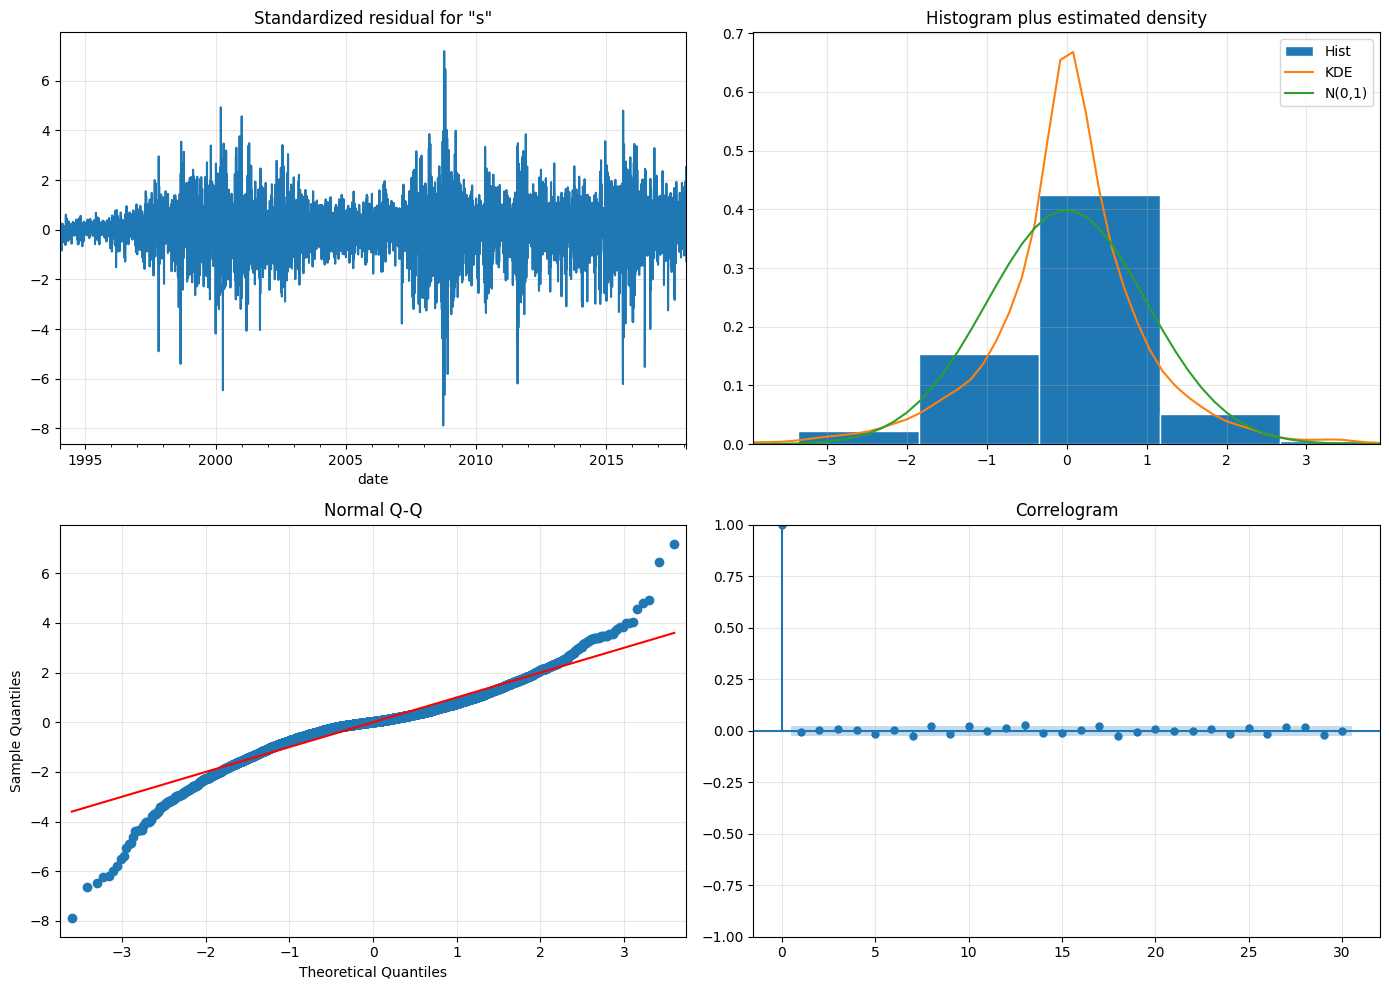

In [17]:
residuos = ajuste.resid.iloc[max(ORDEN_FINAL[0], ORDEN_FINAL[2]) + 1:]

print(f"Media     : {residuos.mean():.6f}")
print(f"Desv. tip.: {residuos.std():.4f}")
print(f"Asimetría : {residuos.skew():.4f}")
print(f"Curtosis  : {residuos.kurtosis():.4f}")

fig = ajuste.plot_diagnostics(figsize=(14, 10), lags=30)
plt.tight_layout()
plt.show()

### 7.1. Contrastes de autocorrelación y normalidad

In [18]:
lb = acorr_ljungbox(residuos, lags=[5, 10, 15, 20, 30], return_df=True)
print("Ljung-Box sobre residuos (H0: no autocorrelación)")
print(lb.to_string())
print("→ Residuos = ruido blanco" if (lb["lb_pvalue"] > 0.05).all()
      else "→ Queda autocorrelación residual")

jb_stat, jb_p, skew_, kurt_ = jarque_bera(residuos)
print(f"\nJarque-Bera: {jb_stat:,.2f} | p-valor: {jb_p:.6f}")
print(f"Asimetría: {skew_:.4f} | Curtosis: {kurt_:.4f}  (normal = 3)")
print("→ NO normales" if jb_p <= 0.05 else "→ Compatibles con normalidad")

Ljung-Box sobre residuos (H0: no autocorrelación)
      lb_stat  lb_pvalue
5    2.209775   0.819423
10  15.612509   0.111275
15  23.086708   0.082316
20  31.232874   0.052190
30  43.554141   0.052315
→ Residuos = ruido blanco

Jarque-Bera: 7,044.13 | p-valor: 0.000000
Asimetría: -0.4570 | Curtosis: 8.1094  (normal = 3)
→ NO normales


### 7.2. Detección de heterocedasticidad condicional

Este es el contraste decisivo para una serie financiera. Si los residuos al cuadrado presentan autocorrelación, la **magnitud** del error de hoy predice la magnitud del error de mañana, aunque no su signo. Es la formalización estadística del agrupamiento de volatilidad que ya se intuía en la Figura 4.

Ljung-Box sobre residuos AL CUADRADO (H0: varianza condicional constante)
        lb_stat  lb_pvalue
5   1723.557937        0.0
10  3181.838003        0.0
15  4112.612080        0.0
20  4947.096670        0.0
30  6190.038509        0.0
→ HAY EFECTOS ARCH


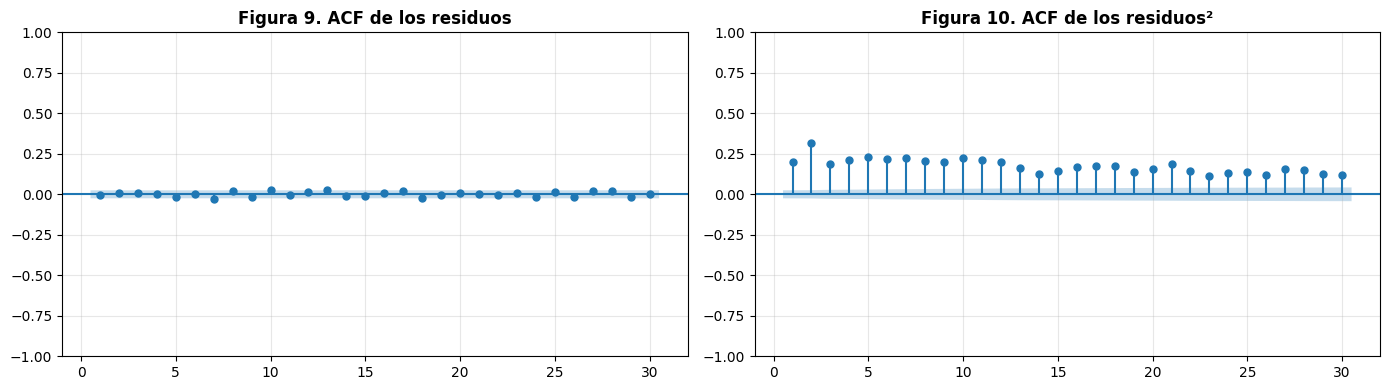

In [19]:
lb_sq = acorr_ljungbox(residuos**2, lags=[5, 10, 15, 20, 30], return_df=True)
print("Ljung-Box sobre residuos AL CUADRADO (H0: varianza condicional constante)")
print(lb_sq.to_string())
print("→ HAY EFECTOS ARCH" if (lb_sq["lb_pvalue"] <= 0.05).any()
      else "→ Varianza constante")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuos, lags=30, ax=axes[0], zero=False)
axes[0].set_title("Figura 9. ACF de los residuos", fontweight="bold")
plot_acf(residuos**2, lags=30, ax=axes[1], zero=False)
axes[1].set_title("Figura 10. ACF de los residuos²", fontweight="bold")
plt.tight_layout()
plt.show()

### 7.3. Métricas de ajuste y validación fuera de muestra

Los criterios de información evalúan el ajuste dentro de la muestra, lo que no garantiza capacidad predictiva real. Completo el diagnóstico con una validación temporal: estimo el modelo sobre el 80% inicial de la muestra y evalúo predicciones **a un paso** sobre el 20% restante, respetando el orden cronológico.

Contrasto los resultados frente a un **modelo ingenuo** (*naïve*: la predicción de mañana es el cierre de hoy). Este es el referente mínimo exigible: si el ARIMA no supera al modelo ingenuo, su valor añadido es nulo por muy favorables que resulten sus criterios de información.

In [20]:
corte = int(len(spx) * 0.8)
train, test = spx.iloc[:corte], spx.iloc[corte:]
print(f"Train: {train.index.min().date()} a {train.index.max().date()} ({len(train)} obs.)")
print(f"Test : {test.index.min().date()} a {test.index.max().date()} ({len(test)} obs.)")

ajuste_train = ARIMA(train, order=ORDEN_FINAL, trend="t").fit()  # coherente con la especificación de la Tarea 6
ajuste_ext = ajuste_train.append(test, refit=False)
pred = ajuste_ext.get_prediction(start=test.index[0]).predicted_mean

naive = test.shift(1)
naive.iloc[0] = train.iloc[-1]

def metricas(y_real, y_pred, nombre):
    y_real, y_pred = np.asarray(y_real, float), np.asarray(y_pred, float)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    print(f"{nombre:<26} RMSE={rmse:8.3f} | MAE={mae:8.3f} | MAPE={mape:6.3f}%")
    return {"Modelo": nombre, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape}

m1 = metricas(test, pred, f"ARIMA{ORDEN_FINAL}")
m2 = metricas(test, naive, "Modelo ingenuo (naïve)")
pd.DataFrame([m1, m2])

Train: 1994-01-07 a 2013-04-05 (5021 obs.)
Test : 2013-04-08 a 2018-01-29 (1256 obs.)
ARIMA(1, 1, 1)             RMSE=  14.755 | MAE=  10.436 | MAPE= 0.518%
Modelo ingenuo (naïve)     RMSE=  14.762 | MAE=  10.404 | MAPE= 0.516%


,Modelo,RMSE,MAE,MAPE (%)
0,"ARIMA(1, 1, 1)",14.754847,10.436403,0.518088
1,Modelo ingenuo (naïve),14.761788,10.404406,0.516326


### 7.4. Representación de las predicciones

Represento primero la predicción a un paso frente a los valores observados en el periodo de validación, y a continuación una previsión a 60 días hábiles con sus intervalos de confianza al 95%, que ilustra el comportamiento del modelo a horizonte largo.

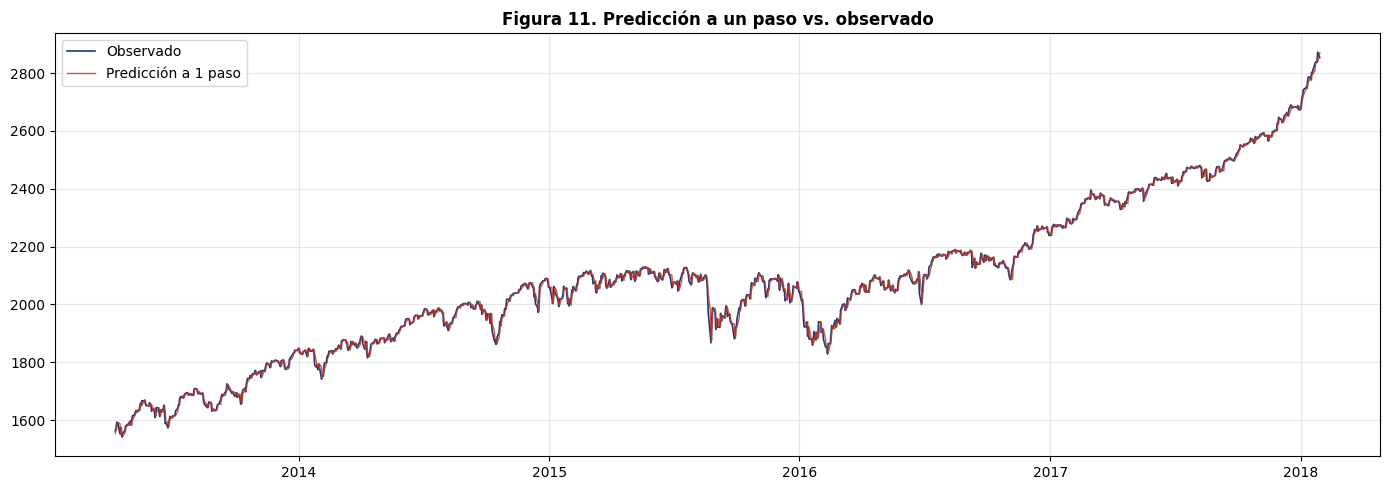

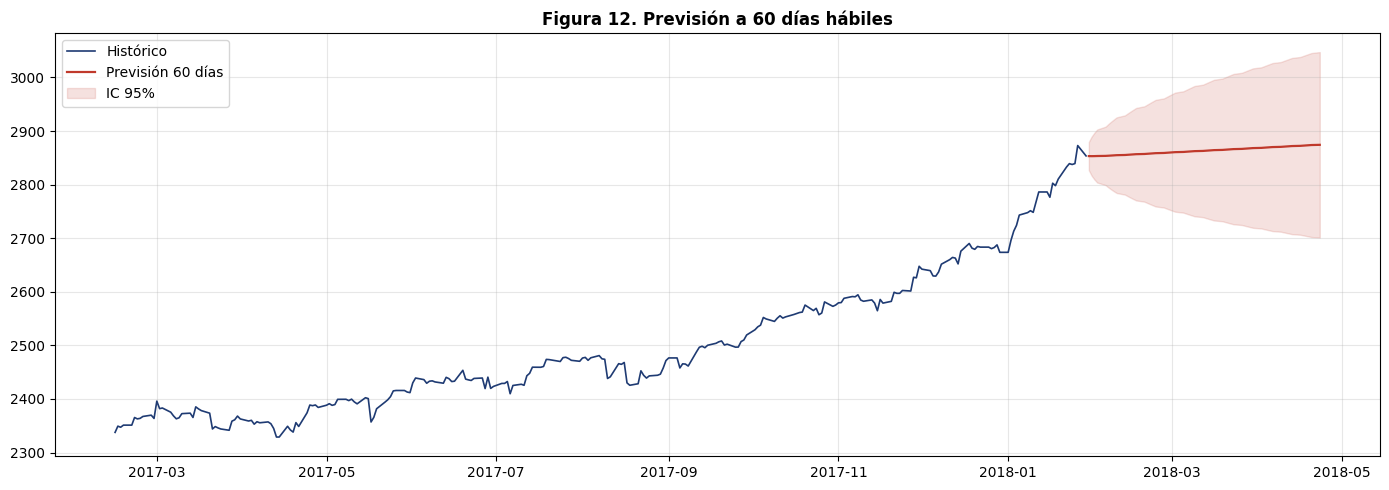

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test.values, label="Observado", linewidth=1.2, color="#1f3b73")
ax.plot(pred.index, pred.values, label="Predicción a 1 paso", linewidth=1.0,
        color="#c0392b", alpha=0.85)
ax.set_title("Figura 11. Predicción a un paso vs. observado", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

f = ajuste.get_forecast(steps=60)
ic = f.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(spx.iloc[-250:], label="Histórico", color="#1f3b73", linewidth=1.2)
ax.plot(f.predicted_mean, label="Previsión 60 días", color="#c0392b", linewidth=1.6)
ax.fill_between(ic.index, ic.iloc[:, 0], ic.iloc[:, 1], color="#c0392b",
                alpha=0.15, label="IC 95%")
ax.set_title("Figura 12. Previsión a 60 días hábiles", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretación del diagnóstico

**1. Autocorrelación de los residuos.** El contraste de Ljung-Box **no rechaza** la hipótesis nula en ninguno de los retardos analizados, aunque conviene matizar el resultado. Los *p*-valores decrecen de forma sistemática con el retardo: 0,819 (5), 0,111 (10), 0,082 (15), 0,052 (20) y 0,052 (30). Los dos últimos se sitúan justo en el límite del 5%, de modo que el no rechazo es holgado en retardos cortos pero marginal en los largos. La ACF de la Figura 9 muestra barras contenidas en las bandas de confianza, y el correlograma del diagnóstico integrado confirma la ausencia de estructura visible. **En cuanto a la estructura lineal en media, el modelo está correctamente especificado**, si bien queda algún residuo de dependencia a largo plazo que una especificación más rica podría capturar.

**2. Normalidad.** El contraste de Jarque-Bera rechaza la normalidad de forma contundente: estadístico de **7.044,13** con *p*-valor nulo. La curtosis de **8,11** —frente al valor 3 de una distribución normal— revela **colas muy pesadas**: Conviene precisar que los estadísticos descriptivos de la celda anterior reportan una curtosis de 5,11 porque `pandas` devuelve el **exceso** sobre la normal, mientras que el resumen del modelo indica 8,11 al reportar la curtosis bruta. Ambas cifras son equivalentes (5,11 + 3 = 8,11) y describen el mismo fenómeno, los eventos extremos son considerablemente más frecuentes de lo que predeciría el supuesto gaussiano. La asimetría negativa de **−0,457** indica además que la cola izquierda es más pesada que la derecha, es decir, que las caídas bruscas son más severas que las subidas equivalentes.

El gráfico Q-Q del diagnóstico integrado ilustra el problema con claridad: los puntos se alinean sobre la recta teórica en el tramo central pero se desvían pronunciadamente en ambos extremos, con residuos estandarizados que alcanzan −8 y +7 desviaciones típicas. Bajo normalidad, una observación a 8 desviaciones tiene una probabilidad del orden de 10⁻¹⁵; en una muestra de 6.277 datos debería ser sencillamente inobservable, y sin embargo aparece. Este es el hecho estilizado que explica por qué los modelos de VaR paramétrico gaussiano subestiman sistemáticamente el riesgo de cola en carteras de renta variable, y por qué la regulación prudencial exige complementarlos con pruebas de estrés y medidas como el *expected shortfall*.

**3. Heterocedasticidad condicional.** Este constituye el hallazgo crítico. El Ljung-Box sobre los residuos al cuadrado rechaza la hipótesis nula con estadísticos que van de **1.723,56** (retardo 5) a **6.190,04** (retardo 30) y *p*-valores exactamente nulos en todos los casos. El contraste de heterocedasticidad que incorpora `statsmodels` en el resumen del modelo apunta en la misma dirección (H = 1,43; *p* = 0,00).

El contraste entre las Figuras 9 y 10 es el resultado más ilustrativo de todo el trabajo. La ACF de los residuos es plana y confinada a las bandas; la de los residuos al cuadrado presenta autocorrelaciones positivas en torno a **0,15–0,30 que se mantienen sin apenas decaer hasta el retardo 30**. El primer panel del diagnóstico integrado lo confirma visualmente: los residuos estandarizados alternan tramos de calma con episodios de alta dispersión concentrados en 1997–1998, 2000–2002 y sobre todo 2008–2009. **Existen efectos ARCH inequívocos y muy persistentes.** El modelo ha extraído toda la estructura disponible en la media, pero no captura absolutamente nada de la dinámica de la varianza, que es donde reside la señal aprovechable de esta serie.

**4. Capacidad predictiva.** Sobre un periodo de validación de 1.256 observaciones (abril 2013 – enero 2018), las métricas fuera de muestra son las siguientes:

| Modelo | RMSE | MAE | MAPE |
|---|---|---|---|
| ARIMA(1,1,1) | 14,755 | 10,436 | 0,518% |
| Modelo ingenuo (*naïve*) | 14,762 | 10,404 | 0,516% |

El ARIMA mejora al modelo ingenuo en RMSE por **0,007 puntos**, una ganancia del **0,05%**, y resulta **ligeramente peor** en MAE y MAPE. Tras estimar tres parámetros sobre 5.021 observaciones, el modelo no bate de forma consistente a la regla más simple imaginable: predecir que mañana el índice cerrará donde cerró hoy. La diferencia carece de cualquier significación práctica.

La Figura 11 explica visualmente el resultado: la predicción a un paso se superpone al valor observado hasta hacer casi indistinguibles ambas líneas a lo largo de todo el periodo, incluidas las correcciones de agosto de 2015 y enero-febrero de 2016. Esta aparente precisión no refleja capacidad predictiva, sino que el modelo **reproduce esencialmente el último valor conocido**, desplazado un periodo.

La Figura 12 desmonta cualquier ilusión de poder predictivo a horizonte largo. La previsión a 60 días hábiles es una **recta prácticamente plana** que parte de unos 2.855 puntos y alcanza los 2.875 al final del horizonte: apenas 20 puntos en tres meses, exactamente la deriva estimada proyectada linealmente (0,3794 × 60 ≈ 23 puntos). Los intervalos de confianza al 95% se abren hasta un rango aproximado de 2.700–3.050 puntos, una amplitud de unos **350 puntos, en torno al 12% del nivel del índice**, siguiendo el patrón en raíz cuadrada del tiempo propio de un proceso integrado. Traducido a negocio: el modelo afirma que dentro de tres meses el S&P 500 estará, con un 95% de confianza, entre un 5% por debajo y un 7% por encima del nivel actual. Es una afirmación cierta pero operativamente inservible.

**Conclusión de la Tarea 7.** El modelo es **estadísticamente aceptable en media pero insatisfactorio en varianza**, y su valor predictivo sobre el nivel del índice es nulo en términos prácticos. Los tres diagnósticos convergen en el mismo mensaje: la estructura lineal de la serie está agotada —y era mínima—, mientras que la estructura de la varianza permanece intacta y sin modelizar. Para un caso de uso de riesgo, que es donde este tipo de modelo tendría recorrido real en una entidad financiera, la especificación resulta insuficiente precisamente porque lo que se necesita medir es la varianza, y es ahí donde el modelo no aporta nada. Este diagnóstico es el que motiva directamente la propuesta de extensión ARIMA-GARCH de la Tarea 8.

## Tarea 8. Propuestas de mejora

A partir de los diagnósticos anteriores planteo cuatro líneas de mejora, ordenadas según el impacto esperado sobre las deficiencias detectadas.

### 8.1. Trabajar con rendimientos logarítmicos en lugar de niveles

La primera diferencia expresada en puntos no es homogénea a lo largo de la muestra: 20 puntos sobre un índice de 500 (1995) y sobre uno de 2.700 (2018) representan variaciones porcentuales radicalmente distintas. El rendimiento logarítmico $r_t = \ln(y_t) - \ln(y_{t-1})$ estabiliza parcialmente la varianza, resulta aditivo en el tiempo y constituye la unidad estándar de trabajo en finanzas cuantitativas.

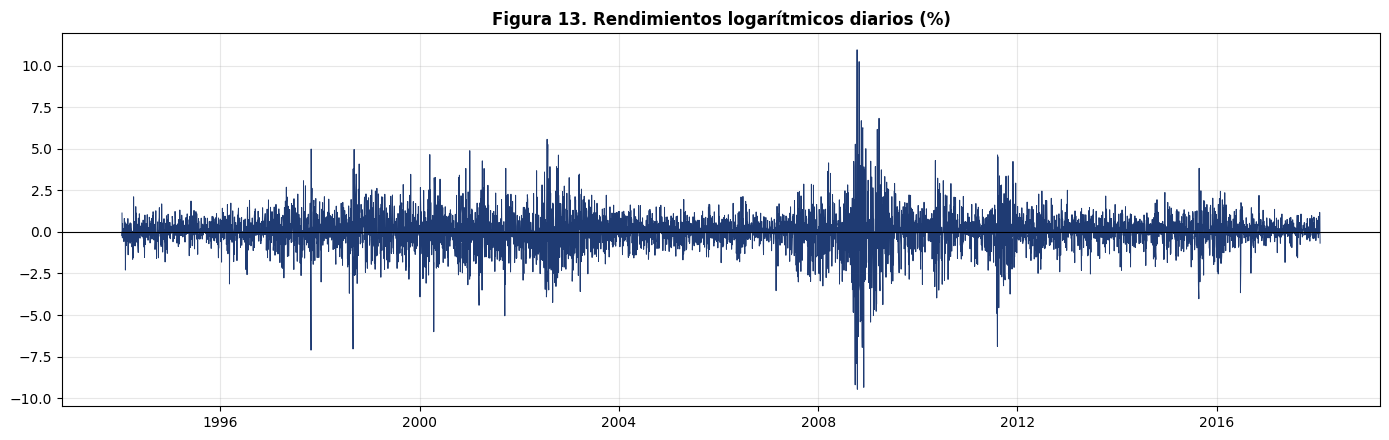

ADF — Rendimientos logarítmicos
Estadístico ADF :     -13.8893
p-valor         :       0.0000
Lags            :           34
Observaciones   :         6241
Valor crítico   1%:    -3.4314
Valor crítico   5%:    -2.8620
Valor crítico  10%:    -2.5670
--------------------------------------------------------------
RECHAZO H0 → ESTACIONARIA

Var(Δspx) en puntos : 183.69
Var(log-returns) %  : 1.2827
Volatilidad anualizada: 17.98%


In [22]:
log_ret = np.log(spx).diff().dropna() * 100

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(log_ret, linewidth=0.7, color="#1f3b73")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Figura 13. Rendimientos logarítmicos diarios (%)", fontweight="bold")
plt.tight_layout()
plt.show()

informe_adf(log_ret, "Rendimientos logarítmicos")
print(f"\nVar(Δspx) en puntos : {spx_d1.var():,.2f}")
print(f"Var(log-returns) %  : {log_ret.var():,.4f}")
print(f"Volatilidad anualizada: {log_ret.std() * np.sqrt(252):.2f}%")

### 8.2. Modelización de la varianza condicional: ARIMA + GARCH

Es la mejora de mayor calado, puesto que ataca directamente la deficiencia principal detectada en la Tarea 7. Un modelo **GARCH(1,1)** especifica la varianza condicional como

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

capturando el agrupamiento de volatilidad. La suma $\alpha + \beta$ mide la **persistencia**: valores próximos a la unidad indican que los shocks de volatilidad se disipan muy lentamente.

Especifico el modelo con distribución **t de Student** para el término de error, lo que aborda simultáneamente el problema de las colas pesadas detectado mediante Jarque-Bera. Para el caso concreto del S&P 500 sería preferible una variante asimétrica (**EGARCH** o **GJR-GARCH**) que recogiese el *efecto apalancamiento*: las caídas incrementan la volatilidad futura en mayor medida que las subidas de igual magnitud.

In [23]:
from arch import arch_model

res_garch = arch_model(log_ret, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
print(res_garch.summary())

alpha = res_garch.params["alpha[1]"]
beta = res_garch.params["beta[1]"]
print(f"\nPersistencia (alpha + beta) = {alpha + beta:.4f}")

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                          spx   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -8133.09
Distribution:      Standardized Student's t   AIC:                           16276.2
Method:                  Maximum Likelihood   BIC:                           16309.9
                                              No. Observations:                 6276
Date:                      Tue, Aug 25 2026   Df Residuals:                     6275
Time:                              11:42:06   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

### 8.2.1. Validación del modelo GARCH

Represento la volatilidad condicional estimada superpuesta a los rendimientos observados y repito el contraste de Ljung-Box sobre los residuos estandarizados al cuadrado. Si los *p*-valores dejan de ser significativos, el modelo ha absorbido los efectos ARCH y el diagnóstico queda cerrado.

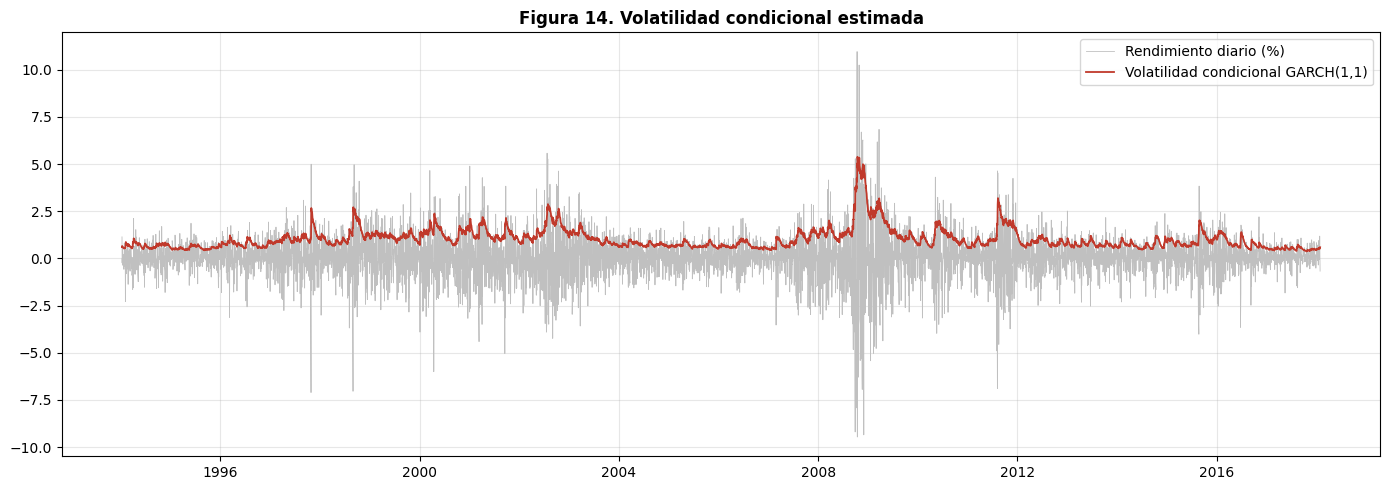

Ljung-Box sobre residuos estandarizados² del GARCH
      lb_stat  lb_pvalue
10  13.513845   0.196343
20  25.378973   0.187315


In [24]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(log_ret.index, log_ret.values, color="#c0c0c0", linewidth=0.6,
        label="Rendimiento diario (%)")
ax.plot(res_garch.conditional_volatility, color="#c0392b", linewidth=1.3,
        label="Volatilidad condicional GARCH(1,1)")
ax.set_title("Figura 14. Volatilidad condicional estimada", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

std_resid = res_garch.std_resid.dropna()
print("Ljung-Box sobre residuos estandarizados² del GARCH")
print(acorr_ljungbox(std_resid**2, lags=[10, 20], return_df=True).to_string())

### Comentario: resultados del modelo GARCH

**Persistencia extrema.** La suma α + β alcanza **0,9999** (α = 0,0855; β = 0,9144), un valor prácticamente indistinguible de la unidad que sitúa el modelo en la frontera del caso **IGARCH**. La interpretación es directa: un shock de volatilidad no se disipa, sino que se incorpora de forma casi permanente al nivel de riesgo de la serie. Es la formalización estadística de algo que se observa en el mercado tras cada episodio de estrés: la volatilidad tarda trimestres, no días, en volver a sus niveles previos. Ambos coeficientes son altamente significativos (t = 7,93 y t = 86,40).

**Confirmación de las colas pesadas.** El parámetro de grados de libertad de la *t* de Student se estima en **ν = 5,46**, muy por debajo del umbral de 30 a partir del cual la distribución converge a la normal. El modelo no solo detecta las colas pesadas, sino que las cuantifica: con ν ≈ 5, los momentos de orden 5 en adelante no existen. Este resultado valida la decisión de especificar el error como *t* en lugar de gaussiano.

**El diagnóstico queda cerrado.** El contraste de Ljung-Box sobre los residuos estandarizados al cuadrado arroja *p*-valores de **0,196** (retardo 10) y **0,187** (retardo 20): **ya no se rechaza la hipótesis nula de varianza condicional constante**. Conviene comparar estas cifras con las del ARIMA puro, donde los mismos contrastes daban estadísticos de 3.182 y 4.947 con *p*-valores exactamente nulos. El GARCH ha absorbido íntegramente los efectos ARCH que el ARIMA dejaba sin modelizar.

La Figura 14 lo muestra visualmente: la volatilidad condicional estimada reproduce con precisión los episodios de 1998, 2000–2002, 2008–2009 y 2015, comprimiéndose en los tramos de calma. Esta es exactamente la variable que necesita una entidad financiera para dimensionar el VaR, calibrar límites de exposición o valorar opciones, y ninguna de esas tres aplicaciones requiere acertar la dirección del mercado.

**Conclusión.** La extensión ARIMA-GARCH resuelve la principal deficiencia detectada en la Tarea 7. Confirma además la tesis central del trabajo: la señal aprovechable de esta serie no está en la media —donde el ARIMA(1,1,1) explica un 0,58% de la variabilidad— sino en la varianza, donde la estructura es abundante, persistente y estadísticamente robusta.

### 8.3. Contraste de la existencia de componente estacional (SARIMA)

El enunciado sugiere valorar una especificación SARIMA. Contrasto explícitamente la existencia de estacionalidad semanal —el llamado *efecto lunes* o *efecto fin de semana*—, que constituiría el único patrón estacional plausible en datos diarios de mercado, con periodo $s=5$ días hábiles.

Examino las autocorrelaciones en los múltiplos de 5 y comparo el rendimiento medio de cada día de la semana.

In [25]:
acf_larga = acf(spx_d1, nlags=30)
print("Autocorrelaciones en múltiplos de 5 (estacionalidad semanal):")
for k in [5, 10, 15, 20, 25, 30]:
    marca = "  ← significativa" if abs(acf_larga[k]) > banda else ""
    print(f"  Retardo {k:>2}: {acf_larga[k]:>8.4f}{marca}")

dias = {0: "Lunes", 1: "Martes", 2: "Miércoles", 3: "Jueves", 4: "Viernes"}
por_dia = log_ret.groupby(log_ret.index.dayofweek).agg(["mean", "std", "count"])
por_dia.index = por_dia.index.map(dias)
print("\nRendimiento logarítmico medio por día de la semana (%)")
print(por_dia.to_string())

Autocorrelaciones en múltiplos de 5 (estacionalidad semanal):
  Retardo  5:  -0.0260  ← significativa
  Retardo 10:   0.0229
  Retardo 15:  -0.0138
  Retardo 20:   0.0114
  Retardo 25:   0.0154
  Retardo 30:   0.0019

Rendimiento logarítmico medio por día de la semana (%)
               mean       std  count
date                                
Lunes      0.013248  1.201157   1256
Martes     0.064642  1.178951   1255
Miércoles  0.030620  1.100228   1255
Jueves     0.019022  1.144904   1255
Viernes    0.016187  1.030412   1255


**Lectura de los resultados.** El retardo 5 supera marginalmente la banda de confianza (−0,0260 frente a ±0,0247), pero se trata del mismo retardo ya identificado en la Tarea 5 dentro del bloque de correlaciones de corto plazo, no de un armónico estacional. La prueba decisiva es que **los múltiplos superiores no lo acompañan**: los retardos 10, 15, 20, 25 y 30 quedan todos dentro de la banda (0,0229; −0,0138; 0,0114; 0,0154; 0,0019) y sin patrón de signo. Una estacionalidad semanal genuina produciría picos sostenidos en toda la secuencia 5, 10, 15..., no uno aislado.

El análisis por día de la semana apunta en la misma dirección. El rendimiento medio del martes (0,0646%) supera al del lunes (0,0132%), pero la desviación típica diaria ronda el 1,1–1,2% con unas 1.255 observaciones por día, lo que sitúa el error típico de cada media en torno al 0,033%. La diferencia observada no llega a dos errores típicos y desaparecería sin dificultad en una submuestra distinta. Sí resulta apreciable el descenso de volatilidad los viernes (1,030%) frente al lunes (1,201%), coherente con el menor volumen de cierre semanal, pero afecta a la varianza y no a la media, de modo que un SARIMA tampoco lo capturaría.

Por tanto, **una especificación SARIMA no está justificada por los datos** y únicamente añadiría parámetros sin mejorar el ajuste. Documento explícitamente este descarte porque considero que rechazar una vía con evidencia tiene tanto valor metodológico como adoptarla.

### 8.4. Otras líneas de mejora

| Línea de mejora | Deficiencia que corrige | Complejidad |
|---|---|---|
| Variables exógenas (ARIMAX/SARIMAX): VIX, tipos de interés, índices rezagados | Ausencia de información externa a la propia serie | Media |
| Estimación sobre submuestra reciente (p. ej. desde 2010) | Cambios estructurales en el régimen de mercado | Baja |
| Distribución *t* de Student o *skew-t* en el error | Colas pesadas y asimetría | Baja |
| Validación con ventana deslizante (*rolling origin*) | Sobreajuste y evaluación poco realista | Media |
| Modelos no lineales (LSTM, *gradient boosting*) | Relaciones no lineales | Alta |

Sobre esta última opción conviene ser prudente. En una entidad financiera, un modelo no lineal de caja negra conlleva un coste de validación y gobernanza —marcos SR 11-7 o TRIM del BCE— muy superior al de un ARIMA-GARCH plenamente documentable. Si la ganancia predictiva sobre el nivel del índice es marginal, como sugiere la comparación con el modelo ingenuo, la especificación parsimoniosa resulta la decisión correcta también desde la óptica del riesgo de modelo.

---

## Conclusiones finales

**1. Sobre la estacionariedad.** La serie de niveles del S&P 500 no es estacionaria: presenta tendencia creciente, media móvil ascendente y una raíz unitaria confirmada de forma concordante por ADF y KPSS. Una única diferencia regular basta para alcanzar estacionariedad en media, de modo que **d = 1**. La segunda diferencia genera sobrediferenciación y queda descartada.

**2. Sobre la identificación.** Las funciones ACF y PACF de la serie diferenciada no muestran cortes limpios y las autocorrelaciones son de magnitud muy reducida. La serie diferenciada se aproxima al ruido blanco, lo que apunta a un proceso **muy próximo a un paseo aleatorio con deriva**. Cabe señalar que el ARIMA(0,1,0) puro quedó en último lugar de los dieciséis candidatos por ambos criterios de información (AIC = 50.531,86; BIC = 50.545,35), de modo que sí existe estructura lineal detectable dentro de la muestra; lo que la validación fuera de muestra demuestra es que esa estructura no resulta aprovechable en términos predictivos.

**3. Sobre el ajuste.** El modelo seleccionado, ARIMA(1,1,1), supera el diagnóstico de autocorrelación en media, pero falla de forma inequívoca en dos frentes: los residuos **no son normales** (Jarque-Bera = 7.044,13; curtosis = 8,11) y presentan **heterocedasticidad condicional** persistente hasta el retardo 30.

**4. Sobre la capacidad predictiva.** Las métricas fuera de muestra resultan prácticamente indistinguibles de las del modelo ingenuo (RMSE 14,755 frente a 14,762), y este último incluso mejora al ARIMA en MAE y MAPE. El modelo no aporta valor predictivo material sobre el nivel del índice.

**5. Sobre la idoneidad del modelo.** Mi valoración es que un ARIMA sobre precios de cierre resulta **adecuado como ejercicio metodológico y como referencia mínima, pero inadecuado como herramienta de decisión** en su forma actual. Su virtud principal reside en que ofrece un diagnóstico riguroso de por qué no funciona: la evidencia es plenamente coherente con la eficiencia débil del mercado. La vía de mejora con recorrido real no está en predecir el **nivel** —donde apenas hay señal—, sino en modelizar la **volatilidad**. La extensión GARCH(1,1) lo confirma: absorbe íntegramente los efectos ARCH y arroja una persistencia de 0,9999, señal de que la estructura de la varianza es abundante, robusta y aprovechable.

**6. Lectura desde mi experiencia profesional.** En asesoramiento a clientes de banca privada, la conversación recurrente es si conviene entrar en mercado ahora o esperar. Este análisis pone números a la respuesta: la estructura predecible del nivel diario del índice es prácticamente nula, de modo que el *market timing* carece de base estadística sobre esta serie. Lo que sí resulta estimable y estable es la **deriva de largo plazo** —95,6 puntos anuales— y la **dinámica de la volatilidad**. Esto es exactamente lo que sostiene el discurso de horizonte temporal, aportación periódica y dimensionamiento de la exposición al riesgo. El modelo no indica hacia dónde irá el mercado, pero sí cuánto puede moverse, y esa segunda pregunta es la que realmente determina si una cartera resulta adecuada para el perfil de un cliente.

---

*Instituto Europeo de Posgrado — Máster en Inteligencia Artificial aplicada al Sector Financiero*